In [8]:
import darshan as dardarbinks
import seaborn as sb
import pandas as pd
import darshan.backend.cffi_backend as backend

dardarbinks.enable_experimental()

from argparse import ArgumentParser
from darshan_helpers import load_dataframe
from darshan_helpers import METADATA_COLUMNS

In [9]:
import ipywidgets as widgets
from ipywidgets import interact, interactive
from IPython.display import display

special_groupings = [
    "operation_types",
    "posix_v_stdio"
]

def args(workdir, exp_type, exp_name, limit_cpu):
    return (workdir, exp_type, exp_name, limit_cpu)

arguments=interactive(args, workdir="../../data/exps", exp_type=["weak_scaling", "strong_scaling"], exp_name=["general"], limit_cpu=False, continuous_update=False)
display(arguments)

interactive(children=(Text(value='../../data/exps', description='workdir'), Dropdown(description='exp_type', o…

In [10]:
# load data
# print(arguments.result)
darshan_data = load_dataframe(arguments.result[0], arguments.result[1], arguments.result[2], arguments.result[3], modules=["POSIX", "STDIO"])
darshan_data = darshan_data.compute()
darshan_data

Parameters:
workdir:  ../../data/exps
experiment_type:  weak_scaling
experiment_name:  general
limit_cpu:  False
modules:  ['POSIX', 'STDIO']
../../data/exps/weak_scaling/general/1/none/false/3/wkwiecin_python_id1969329-1969329_2-19-81909-3433995107726525276_1.darshan
../../data/exps/weak_scaling/general/1/none/false/3/wkwiecin_python_id1969329-1969536_2-19-81960-9563694195135478418_1.darshan
../../data/exps/weak_scaling/general/1/none/false/3/wkwiecin_python_id1969329-1969537_2-19-81960-4384921552611611623_1.darshan
../../data/exps/weak_scaling/general/1/none/false/3/wkwiecin_python_id1969329-1969538_2-19-81960-1914292553865534316_1.darshan
../../data/exps/weak_scaling/general/1/none/false/4/wkwiecin_python_id166164-166164_2-19-84645-17083820981346901398_1.darshan
../../data/exps/weak_scaling/general/1/none/false/4/wkwiecin_python_id166164-166226_2-19-84696-7656263666274622243_1.darshan
../../data/exps/weak_scaling/general/1/none/false/4/wkwiecin_python_id166164-166227_2-19-84696-1099

,file_name,id,process,POSIX_OPENS,POSIX_FILENOS,POSIX_DUPS,POSIX_READS,POSIX_WRITES,POSIX_SEEKS,POSIX_STATS,...,STDIO_F_VARIANCE_RANK_TIME,STDIO_F_VARIANCE_RANK_BYTES,time (s),max_events,nprocs,nthreads,container,limit_cpu,run,basename
0,/tmp/wkwiecin/experiment/athenaMP-workers-Deri...,6855849404978487705,shared_writer,2.0,0.0,0.0,44.0,15000.0,15044.0,0.0,...,NaN,NaN,1155.0,1000,1,0,none,True,3,DAOD_PHYSLITE.pool.root.1
0,/cvmfs/atlas.cern.ch/repo/sw/software/25.0/Ath...,1512557821421132,main,2.0,2.0,0.0,3.0,0.0,1.0,0.0,...,NaN,NaN,1192.0,1000,1,0,none,True,5,libPersistentDataModelDict.so
0,/cvmfs/atlas.cern.ch/repo/sw/software/25.0/Ath...,1512557821421132,main,2.0,2.0,0.0,3.0,0.0,1.0,0.0,...,NaN,NaN,1209.0,1000,1,0,none,True,3,libPersistentDataModelDict.so
0,/cvmfs/atlas.cern.ch/repo/sw/software/25.0/Ath...,1512557821421132,main,2.0,2.0,0.0,3.0,0.0,1.0,0.0,...,NaN,NaN,1194.0,1000,1,0,none,True,6,libPersistentDataModelDict.so
0,/tmp/wkwiecin/experiment/._pathresolver_dummy,2793599151996994491,worker_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,1138.0,1000,1,0,none,True,5,._pathresolver_dummy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3042,/cvmfs/atlas.cern.ch/repo/sw/database/GroupDat...,18438232106454161511,main,2.0,0.0,0.0,378.0,0.0,378.0,0.0,...,NaN,NaN,1373.0,4000,4,0,none,True,4,isolation_ptcorrections_rel20_2.root
3042,/cvmfs/atlas.cern.ch/repo/sw/database/GroupDat...,18438232106454161511,main,2.0,0.0,0.0,378.0,0.0,378.0,0.0,...,NaN,NaN,1378.0,4000,4,0,none,True,1,isolation_ptcorrections_rel20_2.root
3042,/cvmfs/atlas.cern.ch/repo/sw/database/GroupDat...,18438232106454161511,main,2.0,0.0,0.0,378.0,0.0,378.0,0.0,...,NaN,NaN,1360.0,4000,4,0,none,True,3,isolation_ptcorrections_rel20_2.root
3042,/cvmfs/atlas.cern.ch/repo/sw/database/GroupDat...,18438232106454161511,main,2.0,0.0,0.0,378.0,0.0,378.0,0.0,...,NaN,NaN,1364.0,4000,4,0,none,True,2,isolation_ptcorrections_rel20_2.root


<Axes: xlabel='nprocs', ylabel='POSIX_TOTAL'>

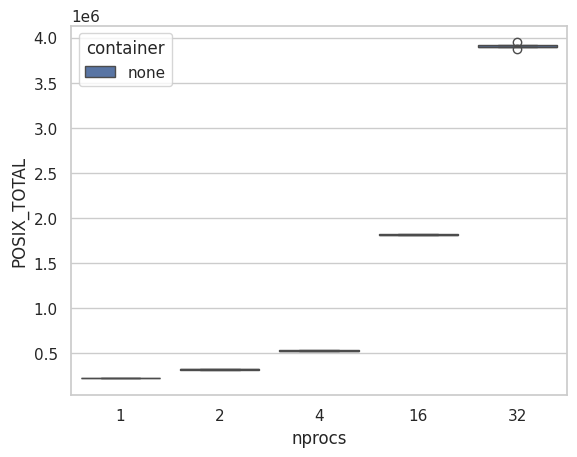

In [11]:
import seaborn as sb

module_operations = [
    "POSIX_OPENS", "POSIX_READS", "POSIX_WRITES", "POSIX_SEEKS", "POSIX_STATS", 
    "POSIX_MMAPS", "POSIX_FSYNCS", "POSIX_FDSYNCS", "STDIO_OPENS", "STDIO_READS",
    "STDIO_WRITES", "STDIO_SEEKS", "STDIO_FLUSHES"
]
df = darshan_data[METADATA_COLUMNS + module_operations]

df["nprocs"] = pd.to_numeric(df["nprocs"])
df["POSIX_TOTAL"] = df[["POSIX_OPENS", "POSIX_READS", "POSIX_WRITES", "POSIX_SEEKS", "POSIX_STATS", 
    "POSIX_MMAPS", "POSIX_FSYNCS", "POSIX_FDSYNCS"]].sum(axis=1, numeric_only=True)
df["STDIO_TOTAL"] = df[["STDIO_OPENS", "STDIO_READS",
    "STDIO_WRITES", "STDIO_SEEKS", "STDIO_FLUSHES"]].sum(axis=1, numeric_only=True)
df = df[METADATA_COLUMNS + ["POSIX_TOTAL", "STDIO_TOTAL"]]
df = df.sort_values(by=["nprocs"])
df = df.groupby(by=["nprocs", "run", "container"]).agg({"POSIX_TOTAL": "sum", "STDIO_TOTAL": "sum"}).reset_index()
df

sb.set_theme(style="whitegrid")
sb.boxplot(data=df, x="nprocs", y="POSIX_TOTAL", hue="container")

In [12]:
# TODO:: include stdio
# MMAPS removed due to bad value (-1), not included in data or metadata ops anyway

module_operations = [
    "POSIX_OPENS", "POSIX_READS", "POSIX_WRITES", "POSIX_SEEKS", "POSIX_STATS", 
    "POSIX_FSYNCS", "POSIX_FDSYNCS", "STDIO_OPENS", "STDIO_READS", 
    "STDIO_WRITES", "STDIO_SEEKS", "STDIO_FLUSHES"
]

df = darshan_data[METADATA_COLUMNS + module_operations]
df["nprocs"] = pd.to_numeric(df["nprocs"])
df["POSIX_METADATA_OPS"] = df[["POSIX_OPENS", "POSIX_SEEKS", "POSIX_STATS"]].sum(axis=1, numeric_only=True)
df["POSIX_DATA_OPS"] = df[["POSIX_READS", "POSIX_WRITES", "POSIX_FSYNCS", "POSIX_FDSYNCS"]].sum(axis=1, numeric_only=True)
df["POSIX_TOTAL"] = df[["POSIX_METADATA_OPS", "POSIX_DATA_OPS"]].sum(axis=1, numeric_only=True)
df["STDIO_METADATA_OPS"] = df[["STDIO_OPENS", "STDIO_SEEKS"]].sum(axis=1, numeric_only=True)
df["STDIO_DATA_OPS"] = df[["STDIO_READS", "STDIO_WRITES"]].sum(axis=1, numeric_only=True)
df["STDIO_TOTAL"] = df[["STDIO_METADATA_OPS", "STDIO_DATA_OPS"]].sum(axis=1, numeric_only=True)
df = df.groupby(by=["nprocs", "run", "container", "file_name"]).agg({
    "process": "unique",
    "POSIX_METADATA_OPS": "sum",
    "POSIX_DATA_OPS": "sum",
    "POSIX_TOTAL": "sum",
    "STDIO_METADATA_OPS": "sum",
    "STDIO_DATA_OPS": "sum",
    "STDIO_TOTAL": "sum"
}).reset_index()
df["access_type"] = df["process"].str.len() == df["nprocs"] + 3
df["access_type"] = df["access_type"].map({True: "global", False: "local"}) # all processes accessed a file
df = df.groupby(by=["nprocs", "run", "container", "access_type"]).agg({
    "POSIX_METADATA_OPS": "sum",
    "POSIX_DATA_OPS": "sum",
    "POSIX_TOTAL": "sum",
    "STDIO_METADATA_OPS": "sum",
    "STDIO_DATA_OPS": "sum",
    "STDIO_TOTAL": "sum"
})
df = df.groupby(by=["nprocs", "container", "access_type"]).agg({
    "POSIX_METADATA_OPS": "mean",
    "POSIX_DATA_OPS": "mean",
    "POSIX_TOTAL": "mean",
    "STDIO_METADATA_OPS": "mean",
    "STDIO_DATA_OPS": "mean",
    "STDIO_TOTAL": "mean"
}).reset_index()
df["GLOBAL_POSIX_METADATA_OPS"] = df.apply(lambda row: row["POSIX_METADATA_OPS"] if row["access_type"] == "global" else 0, axis=1)
df["GLOBAL_POSIX_DATA_OPS"] = df.apply(lambda row: row["POSIX_DATA_OPS"] if row["access_type"] == "global" else 0, axis=1)
df["LOCAL_POSIX_METADATA_OPS"] = df.apply(lambda row: row["POSIX_METADATA_OPS"] if row["access_type"] == "local" else 0, axis=1)
df["LOCAL_POSIX_DATA_OPS"] = df.apply(lambda row: row["POSIX_DATA_OPS"] if row["access_type"] == "local" else 0, axis=1)
df["GLOBAL_STDIO_METADATA_OPS"] = df.apply(lambda row: row["STDIO_METADATA_OPS"] if row["access_type"] == "global" else 0, axis=1)
df["GLOBAL_STDIO_DATA_OPS"] = df.apply(lambda row: row["STDIO_DATA_OPS"] if row["access_type"] == "global" else 0, axis=1)
df["LOCAL_STDIO_METADATA_OPS"] = df.apply(lambda row: row["STDIO_METADATA_OPS"] if row["access_type"] == "local" else 0, axis=1)
df["LOCAL_STDIO_DATA_OPS"] = df.apply(lambda row: row["STDIO_DATA_OPS"] if row["access_type"] == "local" else 0, axis=1)
df.drop(columns=["POSIX_METADATA_OPS", "POSIX_DATA_OPS", "POSIX_TOTAL", "STDIO_METADATA_OPS", "STDIO_DATA_OPS", "STDIO_TOTAL", "access_type"], inplace=True)
# df["TOTAL"] = df.groupby(by=["nprocs", "container", "access_type"])["POSIX_TOTAL"].sum()
df = df.groupby(by=["nprocs", "container"]).agg({
    "GLOBAL_POSIX_METADATA_OPS": "sum",
    "GLOBAL_POSIX_DATA_OPS": "sum",
    "LOCAL_POSIX_METADATA_OPS": "sum",
    "LOCAL_POSIX_DATA_OPS": "sum",
    "GLOBAL_STDIO_METADATA_OPS": "sum",
    "GLOBAL_STDIO_DATA_OPS": "sum",
    "LOCAL_STDIO_METADATA_OPS": "sum",
    "LOCAL_STDIO_DATA_OPS": "sum"
})
df["TOTAL_POSIX_OPS"] = df["GLOBAL_POSIX_METADATA_OPS"] + df["GLOBAL_POSIX_DATA_OPS"] + df["LOCAL_POSIX_METADATA_OPS"] + df["LOCAL_POSIX_DATA_OPS"]
df["TOTAL_STDIO_OPS"] = df["GLOBAL_STDIO_METADATA_OPS"] + df["GLOBAL_STDIO_DATA_OPS"] + df["LOCAL_STDIO_METADATA_OPS"] + df["LOCAL_STDIO_DATA_OPS"]

<Axes: xlabel='nprocs,container'>

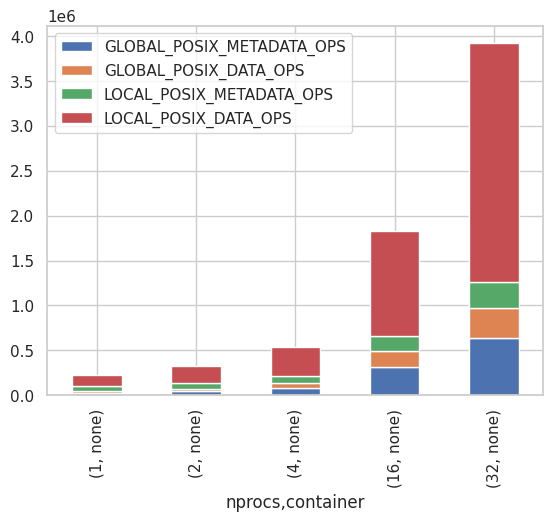

In [13]:
import seaborn as sb
df.plot(kind="bar", y=["GLOBAL_POSIX_METADATA_OPS", "GLOBAL_POSIX_DATA_OPS", "LOCAL_POSIX_METADATA_OPS", "LOCAL_POSIX_DATA_OPS"], stacked=True)

<Axes: xlabel='nprocs,container'>

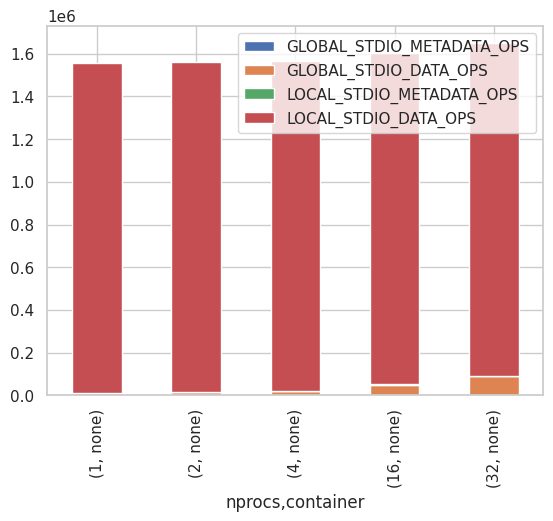

In [14]:
import seaborn as sb
df.plot(kind="bar", y=["GLOBAL_STDIO_METADATA_OPS", "GLOBAL_STDIO_DATA_OPS", "LOCAL_STDIO_METADATA_OPS", "LOCAL_STDIO_DATA_OPS"], stacked=True)

/tmp/ipykernel_2751/1640595047.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=90)


<Axes: title={'center': 'POSIX Data Operation Distribution Among Processes'}, xlabel='process', ylabel='POSIX_READS'>

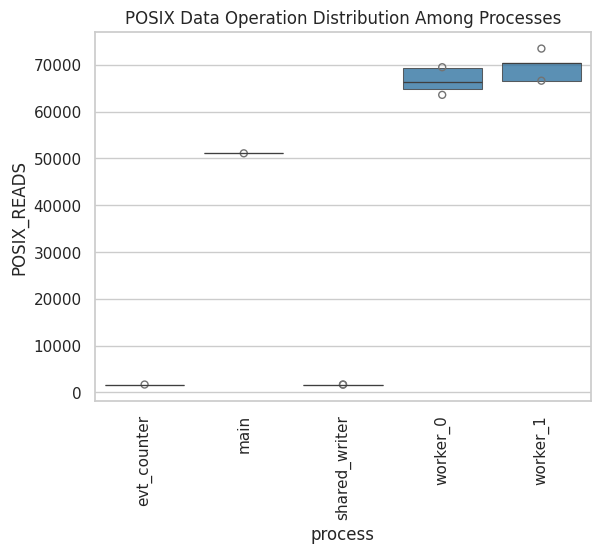

In [51]:
import seaborn as sn
import matplotlib.pyplot as plt
import numpy as np
import re
from natsort import natsort_keygen

def natural_sort_key(s):
    """Convert string into a list of str and int chunks for natural sorting."""
    return [int(c) if c.isdigit() else c.lower() for c in re.split(r'(\d+)', s)]

# find the distribution of reads and writes among processes
distribution_df = darshan_data[METADATA_COLUMNS + ["POSIX_READS", "POSIX_WRITES"]]
distribution_df = distribution_df.drop(columns=["id", "max_events", "limit_cpu"])

distribution_df = distribution_df.groupby(by=["nprocs", "container", "process", "run"]).sum(numeric_only=True).reset_index()
# distribution_df = distribution_df.groupby(by=["nprocs", "container", "process"]).agg({"POSIX_READS": "mean", "POSIX_WRITES": "mean"}).reset_index()
distribution_df

distribution_df["process"] = distribution_df["process"].astype(str)
distribution_df = distribution_df[distribution_df["nprocs"] == 2]

distribution_df.sort_values(by="process", inplace=True, key=natsort_keygen())

sn.set_theme(style='whitegrid')
palette = sn.color_palette('tab10')
color1, color2 = palette[0], palette[1]

plot = sn.boxenplot(data=distribution_df, x="process", y="POSIX_READS", color=color1, alpha=0.8)

plot.set_xticklabels(plot.get_xticklabels(), rotation=90)

# fig, ax1 = plt.subplots(figsize=(9, 5))
# ax2 = ax1.twinx()

# # Compute bar positions manually so the two sets don't overlap
# n = len(distribution_df)
# x = np.arange(n)
# width = 0.35

# # --- Left Y-axis: first bar plot ---
# ax1.bar(x - width / 2, distribution_df['POSIX_READS'], width=width, color=color1, alpha=0.8, label='POSIX_READS')
# ax1.set_ylabel('POSIX_READS', color=color1)
# ax1.tick_params(axis='y', labelcolor=color1)
# ax1.tick_params(axis='x', rotation=90)
# ax1.set_xticks(x)
# ax1.set_xticklabels(distribution_df['process'])
# ax1.set_xlabel('Process')

# # --- Right Y-axis: second bar plot ---
# ax2.bar(x + width / 2, distribution_df['POSIX_WRITES'], width=width, color=color2, alpha=0.8, label='POSIX_WRITES')
# ax2.set_ylabel('POSIX_WRITES', color=color2)
# ax2.tick_params(axis='y', labelcolor=color2)

# # --- Combined legend ---
# handles = [
#     plt.Rectangle((0, 0), 1, 1, color=color1, alpha=0.8),
#     plt.Rectangle((0, 0), 1, 1, color=color2, alpha=0.8)
# ]
# ax1.legend(handles, ['POSIX_READS', 'POSIX_WRITES'], loc='upper left')

plt.title('POSIX Data Operation Distribution Among Processes')
# fig.tight_layout()
# plt.savefig('dual_axis_two_bars.png', dpi=150)
# plt.show()
# fig
plot